# Example 1: How does expected points added (EPA) vary by down and distance?

Tasks

* is 2nd and 3 more efficient than 2nd and 8?
* How bad is 3rd and long?
* What does 1st and 10 usually produce on average?
* Where are teams consistently losing value?
* Heatmaps
* comapare pass vs run EPA by situation
* compare teams across seasons

In [291]:
# Imports
import nfl_data_py as nfl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

In [292]:
# Get play-by-play dataframe
pbp = nfl.import_pbp_data([2024, 2025])
pbp.head()

2024 done.
2025 done.
Downcasting floats.


,play_id,game_id,old_game_id_x,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,was_pressure,route,defense_man_zone_type,defense_coverage_type,offense_names,defense_names,offense_positions,defense_positions,offense_numbers,defense_numbers
0,1.0,2024_01_ARI_BUF,2024090801,BUF,ARI,REG,1,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,40.0,2024_01_ARI_BUF,2024090801,BUF,ARI,REG,1,ARI,away,BUF,...,0.0,,,None,Max Melton;Joey Blount;Dadrion Taylor-Demerson...,Kaiir Elam;Ja'Marcus Ingram;Kameron Cline;Regg...,CB;FS;FS;ILB;ILB;OLB;RB;RB;TE;TE;WR,CB;CB;DE;FB;FS;FS;ILB;ILB;K;RB;TE,16;32;42;51;44;52;20;31;84;87;0,5;46;96;41;21;39;52;54;2;26;85
2,61.0,2024_01_ARI_BUF,2024090801,BUF,ARI,REG,1,ARI,away,BUF,...,0.0,,,None,Evan Brown;Hjalte Froholdt;Will Hernandez;Kyle...,Rasul Douglas;Taron Johnson;Christian Benford;...,C;C;G;QB;RB;T;T;TE;WR;WR;WR,CB;CB;CB;DE;DE;DT;DT;MLB;OLB;SS;SS,62;72;76;1;6;73;70;85;4;14;18,31;7;47;57;50;92;91;43;42;9;3
3,83.0,2024_01_ARI_BUF,2024090801,BUF,ARI,REG,1,ARI,away,BUF,...,0.0,SCREEN,ZONE_COVERAGE,COVER_3,Evan Brown;Hjalte Froholdt;Will Hernandez;Kyle...,Rasul Douglas;Taron Johnson;Christian Benford;...,C;C;G;QB;RB;T;T;TE;TE;WR;WR,CB;CB;CB;DE;DE;DT;DT;MLB;OLB;SS;SS,62;72;76;1;6;73;70;85;87;14;18,31;7;47;57;50;92;91;43;42;9;3
4,108.0,2024_01_ARI_BUF,2024090801,BUF,ARI,REG,1,ARI,away,BUF,...,0.0,HITCH/CURL,ZONE_COVERAGE,COVER_3,Evan Brown;Hjalte Froholdt;Will Hernandez;Kyle...,Rasul Douglas;Taron Johnson;Christian Benford;...,C;C;G;QB;RB;T;T;TE;TE;WR;WR,CB;CB;CB;DE;DE;DT;DT;MLB;OLB;SS;SS,62;72;76;1;6;73;70;85;84;14;18,31;7;47;40;57;92;91;43;42;9;3


In [293]:
# Keep only the columns we need and make a copy of original df
pbp_small = pbp[[
    'down',
    'ydstogo',
    'epa',
    'play_type',
    'posteam',
    'yardline_100',
    'game_id',
    'season',
    'play_id'
]].copy()

pbp_small.head()

,down,ydstogo,epa,play_type,posteam,yardline_100,game_id,season,play_id
0,NaN,0.0,-0.000000,None,None,NaN,2024_01_ARI_BUF,2024,1.0
1,NaN,0.0,0.257819,kickoff,ARI,35.0,2024_01_ARI_BUF,2024,40.0
2,1.0,10.0,-0.200602,run,ARI,70.0,2024_01_ARI_BUF,2024,61.0
3,2.0,7.0,2.028874,pass,ARI,67.0,2024_01_ARI_BUF,2024,83.0
4,1.0,10.0,0.754242,pass,ARI,45.0,2024_01_ARI_BUF,2024,108.0


In [294]:
# Cleaning the dataset to get real offensive plays
# Only keep run and pass plays
# Also taking out 4th down plays bc probablyl more likely to score since at goal line
pbp_clean = pbp_small[
    (pbp_small['down'].isin([1, 2, 3])) &
    (pbp_small['epa'].notna()) &
    (pbp_small['play_type'].isin(['run', 'pass']))
]

pbp_clean.shape

(67659, 9)

In [295]:
# Define distance buckets
def distance_bucket(x):
    if x <= 3:
        return 'short'
    elif x <= 7:
        return 'medium'
    else:
        return 'long'

In [296]:
pbp_clean['distance_bucket'] = pbp_clean['ydstogo'].apply(distance_bucket)

pbp_clean.head()

C:\Users\viole\AppData\Local\Temp\ipykernel_8208\3583364902.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pbp_clean['distance_bucket'] = pbp_clean['ydstogo'].apply(distance_bucket)


,down,ydstogo,epa,play_type,posteam,yardline_100,game_id,season,play_id,distance_bucket
2,1.0,10.0,-0.200602,run,ARI,70.0,2024_01_ARI_BUF,2024,61.0,long
3,2.0,7.0,2.028874,pass,ARI,67.0,2024_01_ARI_BUF,2024,83.0,medium
4,1.0,10.0,0.754242,pass,ARI,45.0,2024_01_ARI_BUF,2024,108.0,long
5,2.0,1.0,-0.029602,run,ARI,36.0,2024_01_ARI_BUF,2024,133.0,short
6,1.0,10.0,-0.247749,run,ARI,34.0,2024_01_ARI_BUF,2024,155.0,long


## EPA by down and distance

In [297]:
epa_summary = (
    pbp_clean
    .groupby(['down', 'distance_bucket', 'play_type'])
    .agg(
        avg_epa=('epa', 'mean'),
        play_count=('epa', 'count')
    ).reset_index()
)
epa_summary

,down,distance_bucket,play_type,avg_epa,play_count
0,1.0,long,pass,0.080956,13787
1,1.0,long,run,-0.069861,14962
2,1.0,medium,pass,-0.071072,301
3,1.0,medium,run,0.070756,608
4,1.0,short,pass,0.076865,182
5,1.0,short,run,0.058745,463
6,2.0,long,pass,0.041388,8262
7,2.0,long,run,-0.079368,3410
8,2.0,medium,pass,0.094956,4017
9,2.0,medium,run,0.024361,3573


In [298]:
# Running play heatmap data
run_heatmap = (
    # filtering to running plays
    epa_summary[
        epa_summary['play_type'] == 'run'
    ]

    .pivot(
        index='down',
        columns='distance_bucket',
        values='avg_epa'
    )
)

# Running play heatmap data
pass_heatmap = (
    # filtering to running plays
    epa_summary[
        epa_summary['play_type'] == 'pass'
    ]

    .pivot(
        index='down',
        columns='distance_bucket',
        values='avg_epa'
    )
)

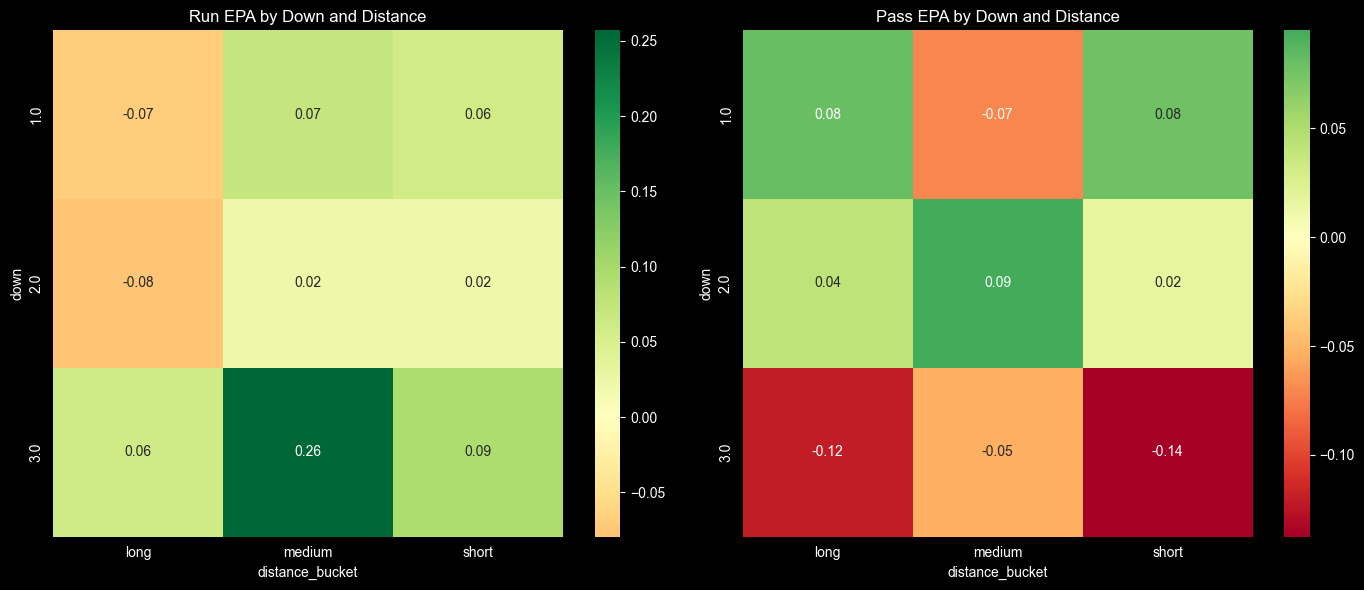

In [299]:
# Heatmap
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,6)
)

sns.heatmap(
    run_heatmap,
    annot=True, # Shows values in box
    fmt='.2f',
    cmap='RdYlGn',
    center=0, # zero epa is neutral
    ax=axes[0]
)

axes[0].set_title('Run EPA by Down and Distance')

sns.heatmap(
    pass_heatmap,
    annot=True, # Shows values in box
    fmt='.2f',
    cmap='RdYlGn',
    center=0, # zero epa is neutral
    ax=axes[1]
)

axes[1].set_title('Pass EPA by Down and Distance')

plt.tight_layout()
plt.show()

EPA for third downs are generally positive when it comes to running plays. Third and medium is the highest among both charts. However, for passing plays, EPA is generally negative. They are actually the only megative values among both charts. Better stick to running on third down.

Let's look at the difference in passing and rushing to confirm which play type is better by down and distance. The heatmap below will show where it's better to pass.

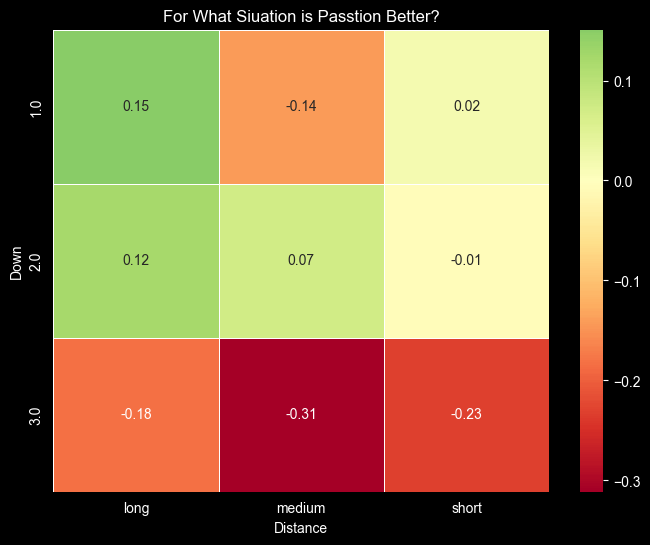

In [300]:
diff_heatmap = pass_heatmap - run_heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    diff_heatmap,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=.5
)

plt.title("For What Siuation is Passtion Better?")
plt.xlabel("Distance")
plt.ylabel("Down")

plt.show()

Longer distances tend to favor passing plays, but any third down play favors rushing. It would be interesting to explore whether or not this could be caused by rushing plays being favored towards the endzoe? Also how is the overall distribution between passing and rushing plays?

## Play Count Distribution by Play Type

In [301]:
# Looking at total distribution by play type
total_play_distribution = (
    pbp_clean['play_type']
    .value_counts()
    .reset_index()
    .rename(columns={
        'index': 'play_type',
        'play_type': 'count'
    })
)

total_play_distribution['percentage'] = (
    total_play_distribution['count'] /
    total_play_distribution['count'].sum()
)

total_play_distribution

,play_type,count,percentage
0,pass,38453,0.568335
1,run,29206,0.431665


C:\Users\viole\AppData\Local\Temp\ipykernel_8208\2745222661.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


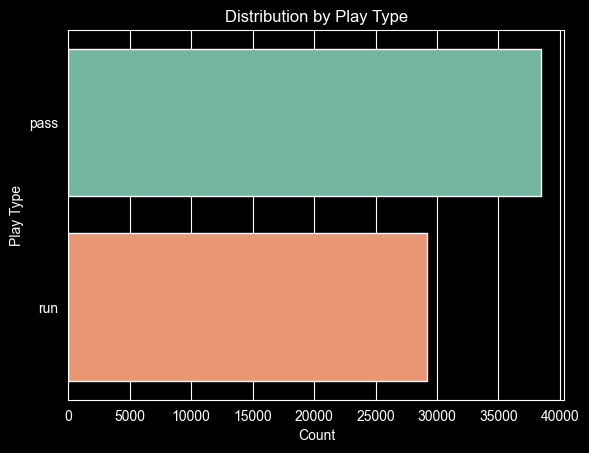

In [302]:
# Bar chart
sns.barplot(
    data=total_play_distribution,
    x='count',
    y='play_type',
    palette='Set2'
)

plt.title('Distribution by Play Type')
plt.xlabel('Count')
plt.ylabel('Play Type')

plt.tight_layout

plt.show()

## Play Count Heat Maps

In [303]:
# Group counts by play_type, down, and distance_bucket
play_counts = (
    pbp_clean
    .groupby([
        'play_type',
        'down',
        'distance_bucket',
    ])
    .size() # returns total number of elements it contains (play count)
    .reset_index(name='count')
)

# Columns are distance bucket and rows are downs
# run plays
run_counts = (
    play_counts[
        play_counts['play_type'] == 'run'
    ]
    .pivot(
        index='down',
        columns='distance_bucket',
        values='count'
    )
    .sort_index()
)

# pass plays
pass_counts = (
      play_counts[
        play_counts['play_type'] == 'pass'
    ]
    .pivot(
        index='down',
        columns='distance_bucket',
        values='count'
    )
    .sort_index()
)

play_count_summary = (
    play_counts
    .groupby(['down', 'distance_bucket', 'play_type'])
    .agg(
        avg_play_count=('count', 'mean'),
        play_count=('count', 'count')
    ).reset_index()
)

play_count_summary

,down,distance_bucket,play_type,avg_play_count,play_count
0,1.0,long,pass,13787.0,1
1,1.0,long,run,14962.0,1
2,1.0,medium,pass,301.0,1
3,1.0,medium,run,608.0,1
4,1.0,short,pass,182.0,1
5,1.0,short,run,463.0,1
6,2.0,long,pass,8262.0,1
7,2.0,long,run,3410.0,1
8,2.0,medium,pass,4017.0,1
9,2.0,medium,run,3573.0,1


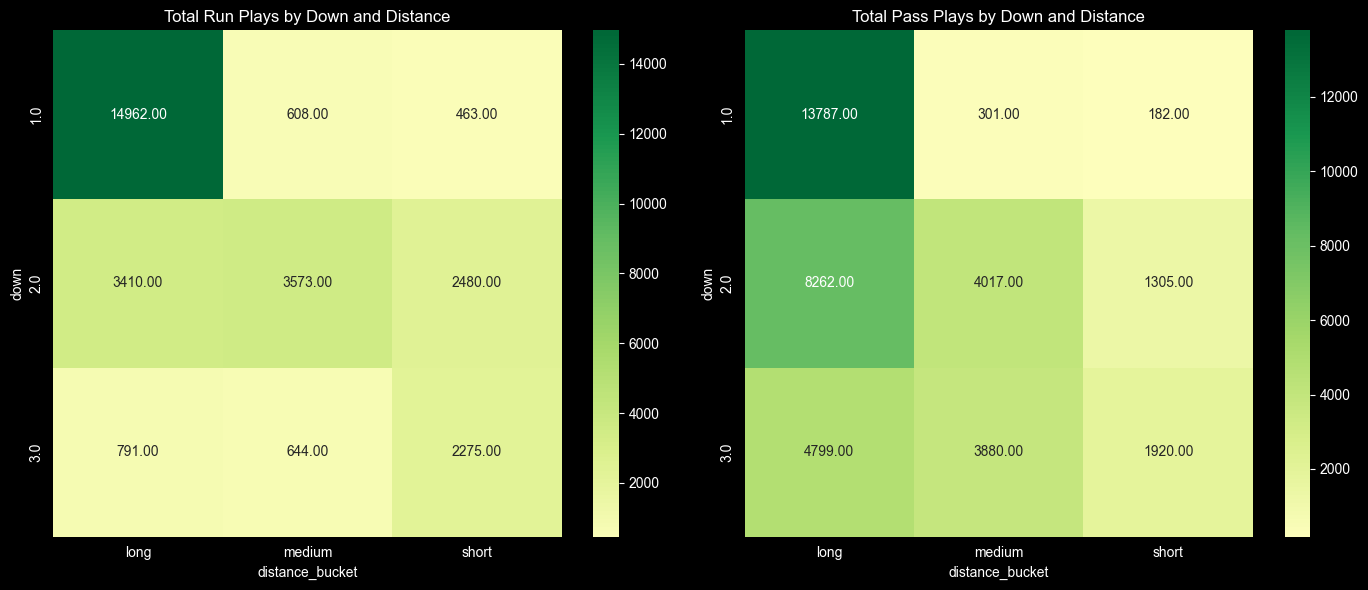

In [304]:
# heatmaps for total plays by play type
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,6)
)

sns.heatmap(
    run_counts,
    annot=True, # Shows values in box
    fmt='.2f',
    cmap='RdYlGn',
    center=0, # zero epa is neutral
    ax=axes[0]
)

axes[0].set_title('Total Run Plays by Down and Distance')

sns.heatmap(
    pass_counts,
    annot=True, # Shows values in box
    fmt='.2f',
    cmap='RdYlGn',
    center=0, # zero epa is neutral
    ax=axes[1]
)

axes[1].set_title('Total Pass Plays by Down and Distance')

plt.tight_layout()
plt.show()

Even though the EPA is higher for running plays on third downs, teams almost always pass more often, except for third and short. Third and Medium had the highest EPA for rushing, but among third down scenarios it's the most likely down for teams to pass. One thing teams are doing right is passing on 1st and long.

## Compare for Panthers across seasons

In [305]:
seasons = [2024, 2025]

pbp_panthers = pbp_clean[
    pbp_clean['posteam'] == 'CAR'
]

pbp_panthers.head()

,down,ydstogo,epa,play_type,posteam,yardline_100,game_id,season,play_id,distance_bucket
350,1.0,10.0,-5.048297,pass,CAR,73.0,2024_01_CAR_NO,2024,239.0,long
357,1.0,10.0,-0.104215,run,CAR,74.0,2024_01_CAR_NO,2024,419.0,long
358,2.0,6.0,0.812479,run,CAR,70.0,2024_01_CAR_NO,2024,441.0,medium
359,1.0,10.0,-0.563456,run,CAR,63.0,2024_01_CAR_NO,2024,463.0,long
360,2.0,9.0,-0.439007,run,CAR,62.0,2024_01_CAR_NO,2024,485.0,long


In [306]:
epa_summary = (
    pbp_panthers
    .groupby([
        'season',
        'play_type',
        'down',
        'distance_bucket',
    ])
    .agg(
        avg_epa=('epa', 'mean'),
        play_count=('epa', 'count')
    )
    .reset_index()
)

epa_summary = epa_summary[
    epa_summary['play_count'] >= 20
]


In [307]:
def create_heatmap(
        df,
        season,
        play_type,
        value_col
):
    data = (
        df[
            (df['season'] == season) &
            (df['play_type'] == play_type)
        ]
        .pivot(
            index='down',
            columns='distance_bucket',
            values=value_col
        )
        .sort_index()
    )

    # Ensure column order
    data = data.reindex(
        columns=[
            'long',
            'medium',
            'short'
        ]
    )

    return data

In [308]:
run_epa_2024 = create_heatmap(
    epa_summary,
    2024,
    'run',
    'avg_epa'
)

run_epa_2025 = create_heatmap(
    epa_summary,
    2025,
    'run',
    'avg_epa'
)

pass_epa_2024 = create_heatmap(
    epa_summary,
    2024,
    'pass',
    'avg_epa'
)

pass_epa_2025 = create_heatmap(
    epa_summary,
    2025,
    'pass',
    'avg_epa'
)

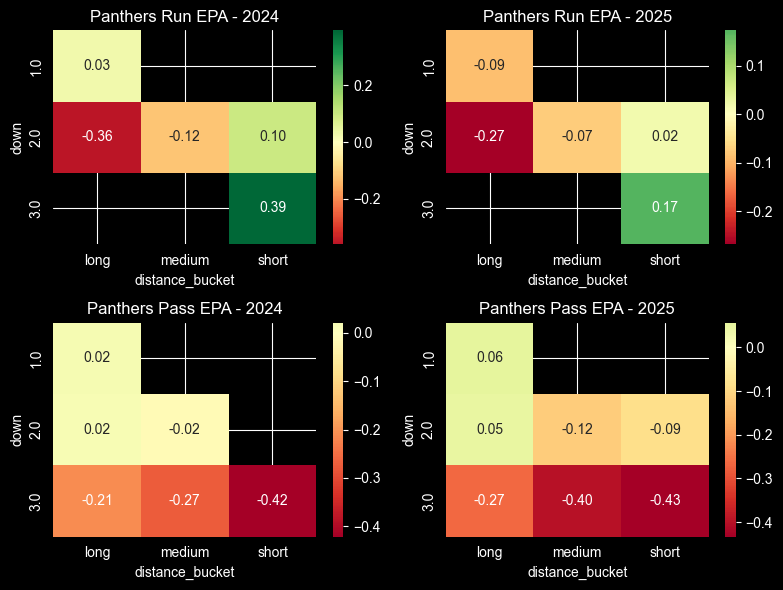

In [315]:
# Plot heatmaps
fig, axes = plt.subplots(
    2,
    2,
    figsize=(8,6)
)

sns.heatmap(
    run_epa_2024,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Panthers Run EPA - 2024')

sns.heatmap(
    run_epa_2025,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Panthers Run EPA - 2025')

sns.heatmap(
    pass_epa_2024,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Panthers Pass EPA - 2024')

sns.heatmap(
    pass_epa_2025,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Panthers Pass EPA - 2025')

plt.tight_layout()
plt.show()